# <center> `Tratamiento series de tasas de paro`

In [400]:
import numpy as np
import pandas as pd
import geopandas as gpd
from unidecode import unidecode

## `lectura de datos`

In [401]:
df1 = pd.read_csv("INE/serie_1976_1995.csv", sep=";", encoding='ISO-8859-1', decimal=',')
df2 = pd.read_csv("INE/serie_1996_2001.csv", sep=";", encoding='ISO-8859-1', decimal=',')
df3 = pd.read_csv("INE/serie_2002_2024.csv", sep=";", encoding='ISO-8859-1', decimal=',')


#Renombre de columnas
df1.rename(columns={"Total": "Tasa"}, inplace=True)
df2.rename(columns={"Total": "Tasa"}, inplace=True)
df3.rename(columns={"Comunidades y Ciudades Autonomas": "Comunidad autonoma"}, inplace=True)
df3.rename(columns={"Total": "Tasa"}, inplace=True)

print("Columnas en serie_1976_1995:\n", df1.columns)
print("\n\nColumnas en serie_1996_2001:\n", df2.columns)
print("\n\nColumnas en serie_2002_2024:\n", df3.columns)


Columnas en serie_1976_1995:
 Index(['Comunidad autonoma', 'Sexo', 'Edad', 'Tasas de actividad y paro',
       'Periodo', 'Tasa'],
      dtype='object')


Columnas en serie_1996_2001:
 Index(['Comunidad autonoma', 'Sexo', 'Edad', 'Tasas de actividad y paro',
       'Periodo', 'Tasa'],
      dtype='object')


Columnas en serie_2002_2024:
 Index(['Sexo', 'Comunidad autonoma', 'Edad', 'Periodo', 'Tasa'], dtype='object')


## `modificar nomenclatura de años`

In [402]:
df1['Periodo'] = df1['Periodo'].apply(lambda x: int(x[:4]))
df2['Periodo'] = df2['Periodo'].apply(lambda x: int(x[:4]))
df3['Periodo'] = df3['Periodo'].apply(lambda x: int(x[:4]))

## `modificar nombre de comunidad`

In [403]:
def normalizar_nombre(nombre_original, reemplazos, extra_param):
    #df1 y df2
    if extra_param:
        nombre = nombre_original.split("(")[0].strip()
    #df3
    else:
        nombre = " ".join(nombre_original.split(",")[0].split()[1:])

    # Buscar coincidencias
    for patron, reemplazo in reemplazos.items():
        if patron in nombre.lower():
            return reemplazo
    return nombre  #si no hay coincidencias

#{patron: reemplazo}
reemplazos_df1_df2 = {
    "asturias": "Asturias",
    "balears": "Balears",
    "mancha": "Castilla La Mancha",
    "madrid": "Madrid",
    "murcia": "Murcia",
    "navarra": "Navarra",
    "rioja": "La Rioja",
    }

reemplazos_df3 = {
    "rioja": "La Rioja",
    "valenciana": "Comunidad Valenciana",
    "mancha": "Castilla La Mancha",
    }

df1["Comunidad autonoma"] = df1["Comunidad autonoma"].apply(lambda x: normalizar_nombre(x, reemplazos_df3, True))
df2["Comunidad autonoma"] = df2["Comunidad autonoma"].apply(lambda x: normalizar_nombre(x, reemplazos_df3, True))
df3["Comunidad autonoma"] = df3["Comunidad autonoma"].apply(lambda x: normalizar_nombre(x, reemplazos_df3, False))


#resultado
pd.DataFrame({"serie_1976_1995": np.append(df1["Comunidad autonoma"].unique(), "-"),
              "serie_1996_2001": np.append(df2["Comunidad autonoma"].unique(), "-"),
              "serie_2002_2024": df3["Comunidad autonoma"].unique()})

,serie_1976_1995,serie_1996_2001,serie_2002_2024
0,Andalucia,Andalucia,Andalucia
1,Aragon,Aragon,Aragon
2,Asturias,Asturias,Asturias
3,Balears,Balears,Balears
4,Canarias,Canarias,Canarias
5,Cantabria,Cantabria,Cantabria
6,Castilla y Leon,Castilla y Leon,Castilla y Leon
7,Castilla La Mancha,Castilla La Mancha,Castilla La Mancha
8,Cataluña,Cataluña,Cataluña
9,Comunidad Valenciana,Comunidad Valenciana,Comunidad Valenciana


## `['Ceuta y Melilla'] a ['Ceuta'] ['Melilla']`

In [404]:
# pasar de "Ceuta y Melilla" a ["Ceuta", "Melilla"]
mask = (df1["Comunidad autonoma"] == "Ceuta y Melilla")
df1.loc[mask,  "Comunidad autonoma"] = df1.loc[mask,  "Comunidad autonoma"].apply(lambda x: ["Ceuta", "Melilla"])

mask = (df2["Comunidad autonoma"] == "Ceuta y Melilla")
df2.loc[mask,  "Comunidad autonoma"] = df2.loc[mask,  "Comunidad autonoma"].apply(lambda x: ["Ceuta", "Melilla"])

#separar la lita ["Ceuta", "Melilla"] a una fila por cada valor
df1 = df1.explode("Comunidad autonoma").reset_index(drop=True)
df2 = df2.explode("Comunidad autonoma").reset_index(drop=True)

#resultado
pd.DataFrame({"serie_1976_1995": df1["Comunidad autonoma"].unique(),
              "serie_1996_2001": df2["Comunidad autonoma"].unique(),
              "serie_2002_2024": df3["Comunidad autonoma"].unique()})

,serie_1976_1995,serie_1996_2001,serie_2002_2024
0,Andalucia,Andalucia,Andalucia
1,Aragon,Aragon,Aragon
2,Asturias,Asturias,Asturias
3,Balears,Balears,Balears
4,Canarias,Canarias,Canarias
5,Cantabria,Cantabria,Cantabria
6,Castilla y Leon,Castilla y Leon,Castilla y Leon
7,Castilla La Mancha,Castilla La Mancha,Castilla La Mancha
8,Cataluña,Cataluña,Cataluña
9,Comunidad Valenciana,Comunidad Valenciana,Comunidad Valenciana


## `resultado`

In [405]:
df = pd.concat([df1, df2, df3])
df_pivot = df.pivot(index="Comunidad autonoma", columns="Periodo", values="Tasa").reset_index()
df_pivot.sort_values(by="Comunidad autonoma").head(20)

Periodo,Comunidad autonoma,1976,1977,1978,1979,1980,1981,1982,1983,1984,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,Andalucia,10.04,11.72,13.88,14.64,18.02,20.30,20.57,23.98,29.95,...,29.83,28.25,24.43,21.26,20.80,22.74,20.31,19.05,17.61,15.76
1,Aragon,2.65,3.20,5.91,6.89,8.71,13.20,12.10,14.89,15.60,...,14.60,13.53,11.37,11.11,9.93,12.49,9.18,9.57,8.17,7.62
2,Asturias,3.01,4.10,5.67,8.05,9.81,12.83,13.86,13.47,17.15,...,20.33,14.59,14.64,12.86,13.14,13.50,10.10,14.18,11.62,8.09
3,Balears,4.49,4.31,4.43,5.36,10.13,11.20,14.01,14.92,13.47,...,17.02,13.80,12.61,10.91,9.91,17.34,14.58,10.70,11.16,8.20
4,Canarias,8.58,8.57,10.19,10.43,13.34,17.66,18.01,19.44,24.08,...,26.75,24.90,22.04,19.99,18.78,25.22,19.23,14.87,16.06,11.91
5,Cantabria,3.57,3.69,4.09,6.43,7.96,11.43,11.98,14.36,14.99,...,17.71,12.89,13.49,9.68,11.18,11.79,11.58,10.53,7.39,8.23
6,Castilla La Mancha,3.94,4.94,6.45,8.71,11.28,14.34,12.99,14.13,16.64,...,24.97,22.14,19.74,16.16,16.56,17.39,13.33,14.81,12.33,11.86
7,Castilla y Leon,3.33,4.73,5.79,7.41,9.56,11.45,12.51,13.78,17.13,...,17.58,14.81,13.71,11.21,11.20,11.61,10.46,8.90,9.59,8.23
8,Cataluña,3.81,4.18,7.06,9.29,13.81,16.97,20.65,21.69,22.29,...,17.73,14.85,12.63,11.75,10.45,13.87,10.21,10.32,9.16,7.87
9,Ceuta,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,23.25,22.39,26.03,24.02,27.58,26.74,31.17,33.34,32.66,21.79


# <center> `Tratamiento de fichero shp`

## `lectura de datos`

<Axes: >

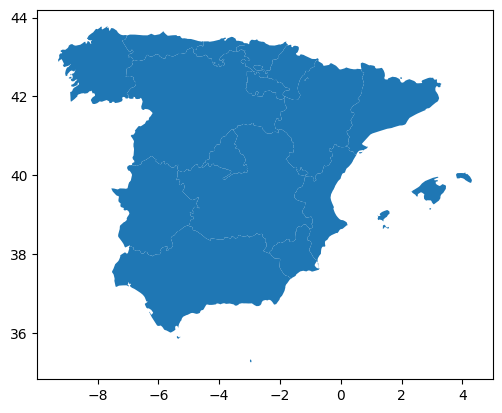

In [406]:
shp = gpd.read_file("Cartografia/se89_10_admin_ccaa_a_x.shp")
shp.plot()

In [407]:
shp.columns

Index(['fecha_alta', 'fecha_baja', 'rotulo', 'id_ccaa', 'x_cvi', 'y_cvi',
       'x_cap', 'y_cap', 'id_inec', 'rotulo2', 'st_area_sh', 'st_length_',
       'geometry'],
      dtype='object')

In [408]:
shp.rename(columns={"rotulo": "Comunidad autonoma"}, inplace=True)
shp = shp.loc[:, ["Comunidad autonoma", "id_ccaa", "geometry"]]
shp.head()

,Comunidad autonoma,id_ccaa,geometry
0,Andalucía,61,"POLYGON ((-5.00801 38.71523, -4.87696 38.6861,..."
1,Aragón,62,"POLYGON ((-0.56759 42.78107, -0.55115 42.77766..."
2,Principado de Asturias,63,"POLYGON ((-4.51231 43.39323, -4.52299 43.36854..."
3,Illes Balears,64,"MULTIPOLYGON (((3.19286 39.93983, 3.15416 39.9..."
4,Cantabria,66,"POLYGON ((-3.15337 43.35325, -3.15097 43.34883..."


## `modificar nombre de comunidad`

In [409]:
#{patron: reemplazo}
reemplazos = {
    "asturias": "Asturias",
    "balears": "Balears",
    "cataluna": "Cataluña",
    "madrid": "Madrid",
    "murcia": "Murcia",
    "navarra": "Navarra",
    "pais": "Pais Vasco",
    "rioja": "La Rioja",
    "valenciana": "Comunidad Valenciana",
    "ceuta": "Ceuta",
    "melilla": "Melilla",
    "mancha": "Castilla La Mancha"
}

def normalizar_nombre(nombre_inicial):
    outName = unidecode(nombre_inicial)
    for patron, reemplazo in reemplazos.items():
        if patron in outName.lower():
            return reemplazo
    return outName  # Si no coincide con ningún patrón, devuelve el original

# Aplicar a la columna del DataFrame
shp["Comunidad autonoma"] = shp["Comunidad autonoma"].apply(normalizar_nombre)
shp.head(20)

,Comunidad autonoma,id_ccaa,geometry
0,Andalucia,61,"POLYGON ((-5.00801 38.71523, -4.87696 38.6861,..."
1,Aragon,62,"POLYGON ((-0.56759 42.78107, -0.55115 42.77766..."
2,Asturias,63,"POLYGON ((-4.51231 43.39323, -4.52299 43.36854..."
3,Balears,64,"MULTIPOLYGON (((3.19286 39.93983, 3.15416 39.9..."
4,Cantabria,66,"POLYGON ((-3.15337 43.35325, -3.15097 43.34883..."
5,Castilla y Leon,67,"MULTIPOLYGON (((-4.78446 43.08356, -4.76652 43..."
6,Castilla La Mancha,68,"POLYGON ((-2.86692 41.27446, -2.8218 41.25836,..."
7,Cataluña,69,"MULTIPOLYGON (((0.90621 42.8012, 0.93291 42.79..."
8,Extremadura,70,"POLYGON ((-5.93777 40.28106, -5.92083 40.28089..."
9,Galicia,71,"MULTIPOLYGON (((-7.6625 43.77427, -7.69975 43...."


## `Union series de datos con fichero shp`

In [410]:
#merge - left join
df_final = shp.merge(df_pivot, on="Comunidad autonoma", how="left")
df_final.head(20)

,Comunidad autonoma,id_ccaa,geometry,1976,1977,1978,1979,1980,1981,1982,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,Andalucia,61,"POLYGON ((-5.00801 38.71523, -4.87696 38.6861,...",10.04,11.72,13.88,14.64,18.02,20.30,20.57,...,29.83,28.25,24.43,21.26,20.80,22.74,20.31,19.05,17.61,15.76
1,Aragon,62,"POLYGON ((-0.56759 42.78107, -0.55115 42.77766...",2.65,3.20,5.91,6.89,8.71,13.20,12.10,...,14.60,13.53,11.37,11.11,9.93,12.49,9.18,9.57,8.17,7.62
2,Asturias,63,"POLYGON ((-4.51231 43.39323, -4.52299 43.36854...",3.01,4.10,5.67,8.05,9.81,12.83,13.86,...,20.33,14.59,14.64,12.86,13.14,13.50,10.10,14.18,11.62,8.09
3,Balears,64,"MULTIPOLYGON (((3.19286 39.93983, 3.15416 39.9...",4.49,4.31,4.43,5.36,10.13,11.20,14.01,...,17.02,13.80,12.61,10.91,9.91,17.34,14.58,10.70,11.16,8.20
4,Cantabria,66,"POLYGON ((-3.15337 43.35325, -3.15097 43.34883...",3.57,3.69,4.09,6.43,7.96,11.43,11.98,...,17.71,12.89,13.49,9.68,11.18,11.79,11.58,10.53,7.39,8.23
5,Castilla y Leon,67,"MULTIPOLYGON (((-4.78446 43.08356, -4.76652 43...",3.33,4.73,5.79,7.41,9.56,11.45,12.51,...,17.58,14.81,13.71,11.21,11.20,11.61,10.46,8.90,9.59,8.23
6,Castilla La Mancha,68,"POLYGON ((-2.86692 41.27446, -2.8218 41.25836,...",3.94,4.94,6.45,8.71,11.28,14.34,12.99,...,24.97,22.14,19.74,16.16,16.56,17.39,13.33,14.81,12.33,11.86
7,Cataluña,69,"MULTIPOLYGON (((0.90621 42.8012, 0.93291 42.79...",3.81,4.18,7.06,9.29,13.81,16.97,20.65,...,17.73,14.85,12.63,11.75,10.45,13.87,10.21,10.32,9.16,7.87
8,Extremadura,70,"POLYGON ((-5.93777 40.28106, -5.92083 40.28089...",5.85,8.03,10.10,15.20,15.41,17.59,17.44,...,28.07,28.31,25.12,23.10,23.48,21.32,19.33,17.55,16.23,15.26
9,Galicia,71,"MULTIPOLYGON (((-7.6625 43.77427, -7.69975 43....",1.82,2.19,2.50,4.39,5.83,6.57,8.70,...,17.74,16.29,14.71,12.04,11.74,11.66,10.94,10.65,9.19,8.67


In [411]:
#cambio de nombre de columna
df_final.rename(columns={"Comunidad autonoma": "CCAA"}, inplace=True)

#nombres de columnas a str
df_final.columns = df_final.columns.astype(str)

## `guardar shp resultado`

In [412]:
outfp = "Cartografia/CCAA.shp"
df_final.to_file(outfp, driver="ESRI Shapefile", encoding="utf-8")